In [1]:
pip install matplotlib seaborn wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.3/551.3 kB 10.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Carregar o dataset limpo
df = pd.read_csv('dataset_parental_link.csv')

# Visão geral das colunas e tipos de dados
print("--- Informações do Dataset ---")
print(df.info())

# Verificar se há valores nulos (mensagens em branco)
print("\n--- Valores Nulos ---")
print(df.isnull().sum())

# Se houver mensagens nulas, você pode removê-las assim:
df = df.dropna(subset=['texto'])

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 19272 entries, 0 to 19271
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          19272 non-null  int64
 1   texto       19272 non-null  str  
 2   autor       19272 non-null  str  
 3   comunidade  19272 non-null  str  
 4   label       19272 non-null  str  
dtypes: int64(1), str(4)
memory usage: 752.9 KB
None

--- Valores Nulos ---
id            0
texto         0
autor         0
comunidade    0
label         0
dtype: int64


Contagem de cada classe:
 label
F    14842
T     4430
Name: count, dtype: int64

Proporção (%) de cada classe:
 label
F    77.013284
T    22.986716
Name: proportion, dtype: float64


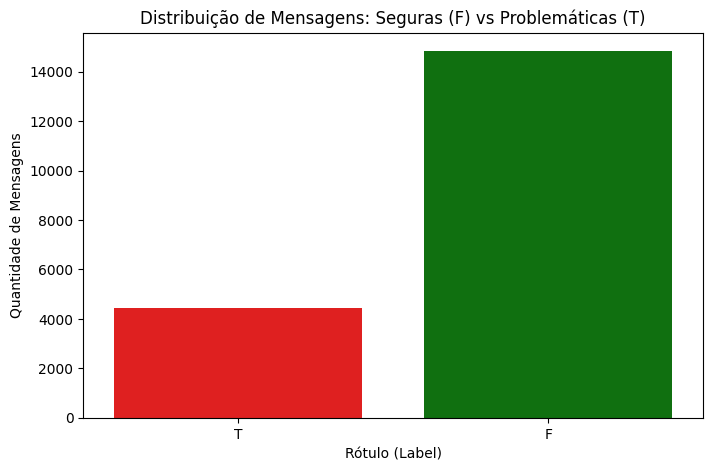

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem exata
contagem_classes = df['label'].value_counts()
print("Contagem de cada classe:\n", contagem_classes)
print("\nProporção (%) de cada classe:\n", df['label'].value_counts(normalize=True) * 100)

# Gráfico de barras para o TCC (fica ótimo no documento final)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', hue='label', palette={'F': 'green', 'T': 'red'}, legend=False)
plt.title('Distribuição de Mensagens: Seguras (F) vs Problemáticas (T)')
plt.xlabel('Rótulo (Label)')
plt.ylabel('Quantidade de Mensagens')
plt.show()

--- Estatísticas do tamanho das mensagens (em palavras) ---
count    19272.000000
mean        29.132005
std         46.710451
min          1.000000
25%          9.000000
50%         15.000000
75%         30.000000
max        829.000000
Name: num_palavras, dtype: float64


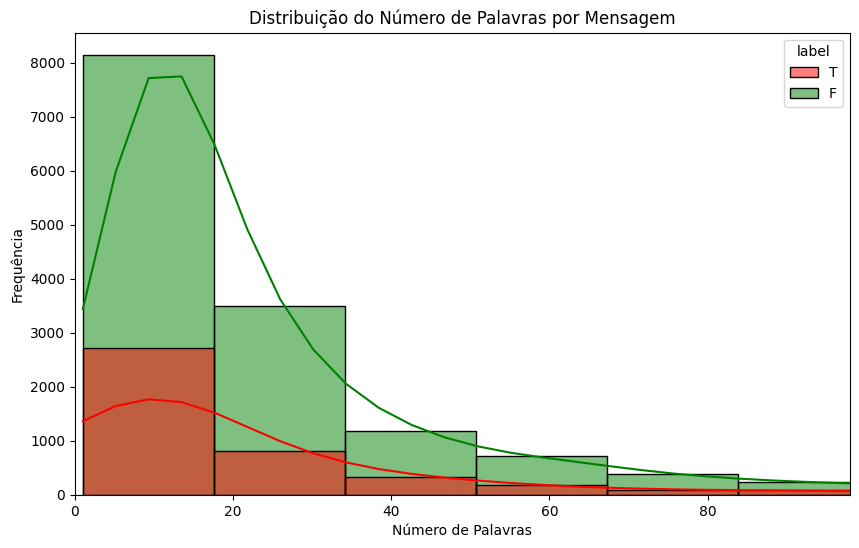

In [4]:
# Criar uma nova coluna com a quantidade de palavras de cada mensagem
df['num_palavras'] = df['texto'].apply(lambda x: len(str(x).split()))

print("--- Estatísticas do tamanho das mensagens (em palavras) ---")
print(df['num_palavras'].describe())

# Gráfico de distribuição do tamanho das mensagens
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_palavras', hue='label', bins=50, kde=True, palette={'F': 'green', 'T': 'red'})
plt.title('Distribuição do Número de Palavras por Mensagem')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.xlim(0, df['num_palavras'].quantile(0.95)) # Foca nos 95% menores para ignorar outliers gigantes
plt.show()

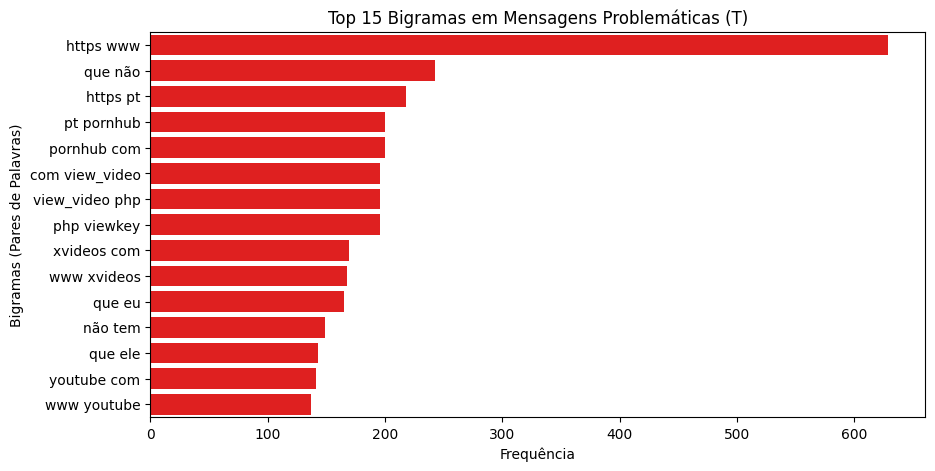

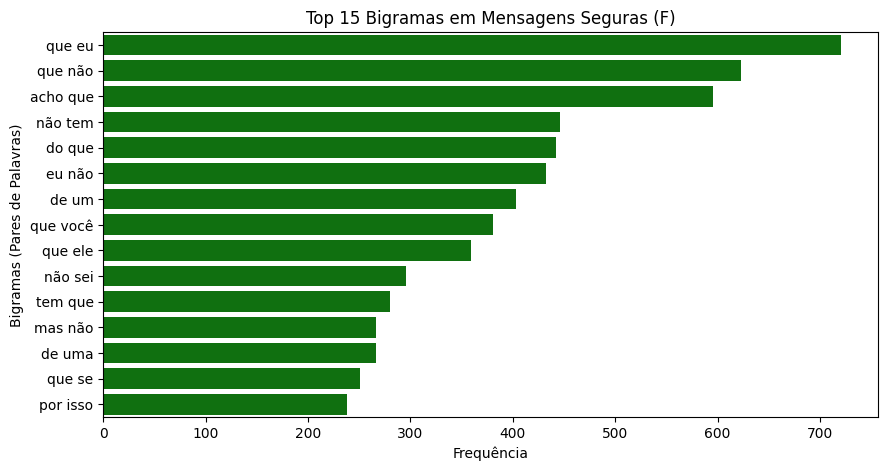

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_bigramas(df, label, cor, titulo):
    # Pega apenas os textos da classe específica
    textos = df[df['label'] == label]['texto'].dropna().astype(str)
    
    # Configura o vetorizador para pegar pares de palavras (ngram_range=(2,2))
    vetorizador = CountVectorizer(ngram_range=(2, 2), max_features=15)
    matriz = vetorizador.fit_transform(textos)
    
    # Soma a frequência de cada par
    soma_palavras = matriz.sum(axis=0)
    frequencias = [(palavra, soma_palavras[0, idx]) for palavra, idx in vetorizador.vocabulary_.items()]
    frequencias = sorted(frequencias, key=lambda x: x[1], reverse=True)
    
    # Separa para o gráfico
    pares = [x[0] for x in frequencias]
    contagens = [x[1] for x in frequencias]
    
    # Plota o gráfico
    plt.figure(figsize=(10, 5))
    sns.barplot(x=contagens, y=pares, color=cor)
    plt.title(titulo)
    plt.xlabel('Frequência')
    plt.ylabel('Bigramas (Pares de Palavras)')
    plt.show()

# Rodar para mensagens Problemáticas (T)
plotar_bigramas(df, 'T', 'red', 'Top 15 Bigramas em Mensagens Problemáticas (T)')

# Rodar para mensagens Seguras (F)
plotar_bigramas(df, 'F', 'green', 'Top 15 Bigramas em Mensagens Seguras (F)')

In [7]:
!pip install nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.8/799.8 kB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import re
import unicodedata

nltk.download('stopwords')

# Carregar dataset
df = pd.read_csv('dataset_parental_link.csv')

# 1. Carregar stopwords base
stop_words_pt = set(stopwords.words('portuguese'))

# 2. SALVAR AS NEGATIVAS (Crucial para análise de toxicidade/sentimento)
palavras_para_manter = {'não', 'nao', 'nem', 'nunca', 'jamais', 'sem'}
stop_words_pt = stop_words_pt.difference(palavras_para_manter)

# 3. Adicionar gírias e abreviações comuns de chat
palavras_extras_para_remover = {
    'bem', 'assim', 'ainda', 'pq', 'pra', 'aí', 'etc', 
    'vc', 'vcs', 'q', 'tbm', 'tb', 'to', 'tô', 'ta', 'tá', 'ai', 'la', 'lá', 'ja', 'já'
}
stop_words_pt.update(palavras_extras_para_remover)

def limpar_texto(texto):
    # Converte para minúsculo e transforma em string
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')
    # Remove pontuações (mantém apenas letras, números e espaços)
    texto = re.sub(r'[^\w\s]', '', texto)
    
    # Remove as stopwords ajustadas
    palavras = texto.split()
    palavras_limpas = [palavra for palavra in palavras if palavra not in stop_words_pt]
    
    return " ".join(palavras_limpas)

# Aplicar a limpeza
df['texto_limpo'] = df['texto'].apply(limpar_texto)

print("Limpeza concluída com sucesso!")
print(df[['texto', 'texto_limpo']].head()) 

df.to_csv('dataset_parental_limpoStopWord.csv', index=False)
print("Arquivo exportado com sucesso para 'dataset_parental_limpoStopWord.csv'!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Limpeza concluída com sucesso!
                                               texto  \
0               Já avisei que vai dar merda isso ai.   
1   https://br.spankbang.com/48uay/video/shutter+bug   
2  https://br.spankbang.com/4j5x4/video/tiny+teen...   
3  https://pt.pornhub.com/view_video.php?viewkey=...   
4  https://pt.pornhub.com/view_video.php?viewkey=...   

                                         texto_limpo  
0                               avisei vai dar merda  
1            httpsbrspankbangcom48uayvideoshutterbug  
2  httpsbrspankbangcom4j5x4videotinyteenthroatedt...  
3  httpsptpornhubcomview_videophpviewkeyph5b35d45...  
4  httpsptpornhubcomview_videophpviewkeyph5a0daab...  
Arquivo exportado com sucesso para 'dataset_parental_limpoStopWord.csv'!


In [13]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

# 1. Carregar as bases
df = pd.read_csv('dataset_parental_limpoStopWord.csv') 
df_sex = pd.read_csv('LR_sexslang.csv', header=None)
df_insultos = pd.read_csv('LR_listofinsults.csv', header=None)

# ==========================================
# FASE 1: O SPLIT (Separação Científica)
# ==========================================
print("Iniciando separação dos dados...")

# O 'test_size=0.20' separa 20% para teste e 80% para treino.
# O 'random_state=42' garante que a divisão seja a mesma toda vez que rodar o código (Reprodutibilidade).
# O 'stratify=df['label']' garante que a proporção original de mensagens T e F se mantenha igual nas duas bases.
df_treino, df_teste = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])

# ==========================================
# FASE 2: Base de Teste
# ==========================================
# Salvamos a base de teste IMACULADA, apenas com rótulos humanos e regras de URL.
colunas_finais = ['id', 'texto', 'texto_limpo', 'label']
df_teste[colunas_finais].to_csv('dataset_teste_puro.csv', index=False)


# ==========================================
# FASE 3: ENRIQUECIMENTO (Apenas no Treino)
# ==========================================
print("Aplicando dicionários léxicos na base de Treino...")

palavras_sexuais = df_sex[0].dropna().astype(str).str.lower().tolist()
palavras_ofensivas = df_insultos[0].dropna().astype(str).str.lower().tolist()

regex_sex = r'\b(?:' + '|'.join(map(re.escape, palavras_sexuais)) + r')\b'
regex_insultos = r'\b(?:' + '|'.join(map(re.escape, palavras_ofensivas)) + r')\b'

mascara_sex = df_treino['texto_limpo'].astype(str).str.contains(regex_sex, case=False, regex=True, na=False)
mascara_insultos = df_treino['texto_limpo'].astype(str).str.contains(regex_insultos, case=False, regex=True, na=False)

# Atualizar a coluna label apenas no df_treino.
# Usamos .loc para garantir a alteração segura no Pandas.
df_treino.loc[mascara_sex | mascara_insultos, 'label'] = 'T'

df_treino[colunas_finais].to_csv('dataset_treino_enriquecido.csv', index=False)

# ==========================================
# RESULTADOS
# ==========================================
print("-" * 40)
print("PROCESSO DE SEPARAÇÃO E ENRIQUECIMENTO CONCLUÍDO!")
print(f"Base de Treino (Para ensinar a IA): {len(df_treino)} mensagens salvas em 'dataset_treino_enriquecido.csv'")
print(f"Base de Teste (Santuário Intacto): {len(df_teste)} mensagens salvas em 'dataset_teste_puro.csv'")
print("-" * 40)
print("\nDistribuição da Base de Teste (Mundo Real):")
print(df_teste['label'].value_counts(normalize=True).round(4) * 100) # Mostra em porcentagem (%)
print("\nDistribuição da Base de Treino (Após Dicionários):")
print(df_treino['label'].value_counts(normalize=True).round(4) * 100) # Mostra em porcentagem (%)

Iniciando separação dos dados...
Aplicando dicionários léxicos na base de Treino...
----------------------------------------
PROCESSO DE SEPARAÇÃO E ENRIQUECIMENTO CONCLUÍDO!
Base de Treino (Para ensinar a IA): 15417 mensagens salvas em 'dataset_treino_enriquecido.csv'
Base de Teste (Santuário Intacto): 3855 mensagens salvas em 'dataset_teste_puro.csv'
----------------------------------------

Distribuição da Base de Teste (Mundo Real):
label
F    77.02
T    22.98
Name: proportion, dtype: float64

Distribuição da Base de Treino (Após Dicionários):
label
F    63.44
T    36.56
Name: proportion, dtype: float64


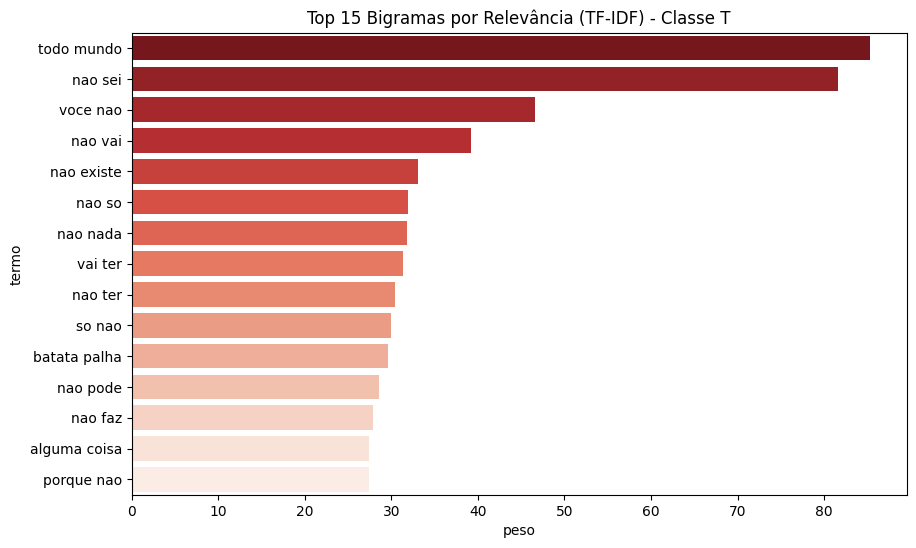

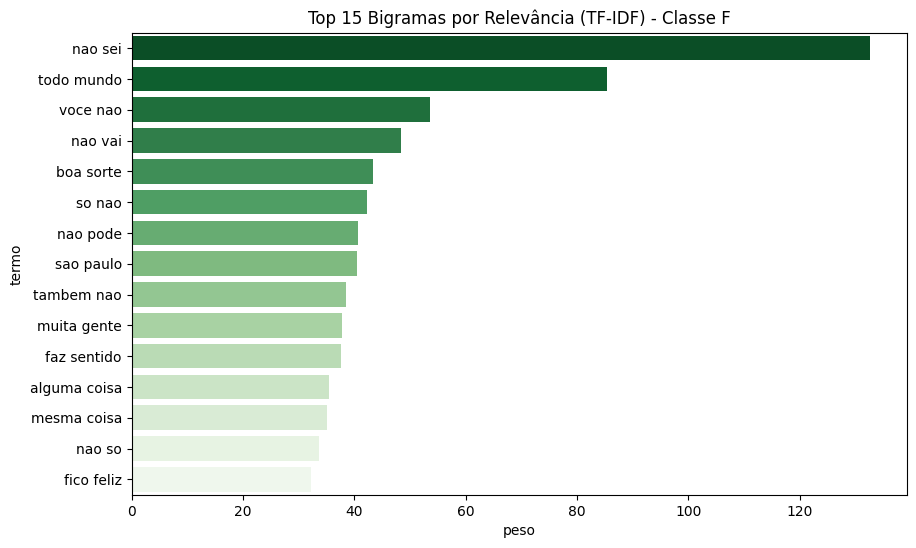

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analise_tfidf_comparativa(df):
    # Criamos o vetorizador TF-IDF
    tfidf = TfidfVectorizer(ngram_range=(2, 2), max_features=100)
    
    for classe, cor in [('T', 'Reds_r'), ('F', 'Greens_r')]:
        # --- CORREÇÃO AQUI: Removemos nulos e strings vazias antes de processar ---
        textos = df[df['label'] == classe]['texto_limpo'].copy()
        textos = textos.dropna().astype(str)
        textos = textos[textos.str.strip() != ""] # Remove mensagens que só tem espaços
        
        if len(textos) == 0:
            print(f"Sem dados suficientes para a classe {classe}")
            continue

        # Ajusta e transforma
        try:
            matriz_tfidf = tfidf.fit_transform(textos)
            
            # Soma os pesos de cada bigrama
            pesos = matriz_tfidf.sum(axis=0).A1
            termos = tfidf.get_feature_names_out()
            
            # Cria um DataFrame para facilitar o plot
            df_tfidf = pd.DataFrame({'termo': termos, 'peso': pesos})
            df_tfidf = df_tfidf.sort_values(by='peso', ascending=False).head(15)
            
            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(x='peso', y='termo', data=df_tfidf, hue='termo', palette=cor, legend=False)
            plt.title(f'Top 15 Bigramas por Relevância (TF-IDF) - Classe {classe}')
            plt.show()
        except ValueError:
            print(f"Não foi possível extrair bigramas para a classe {classe} (termos insuficientes).")

# Execute a análise
df_treino = pd.read_csv('dataset_treino_enriquecido.csv')
analise_tfidf_comparativa(df_treino)

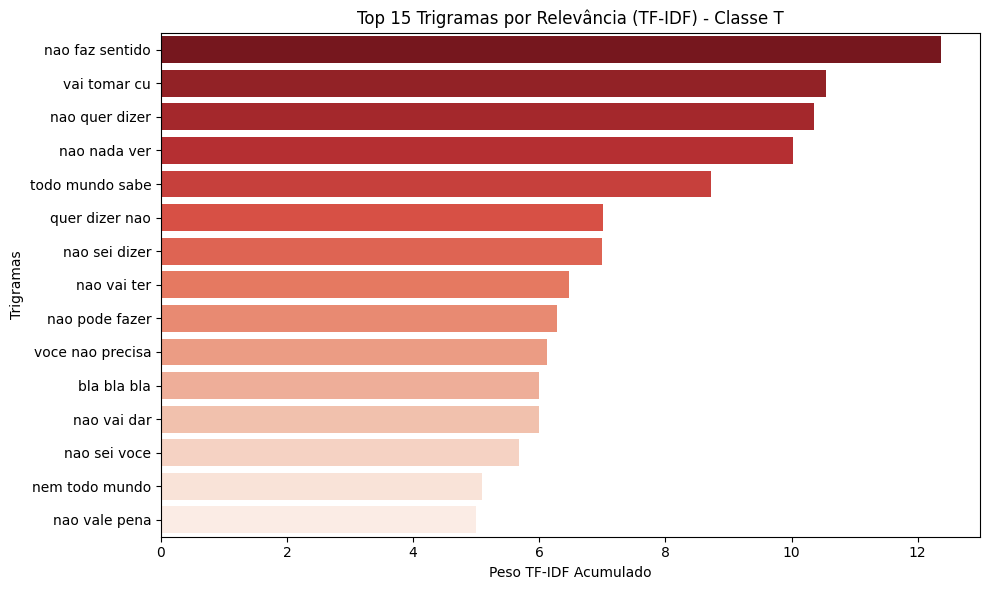

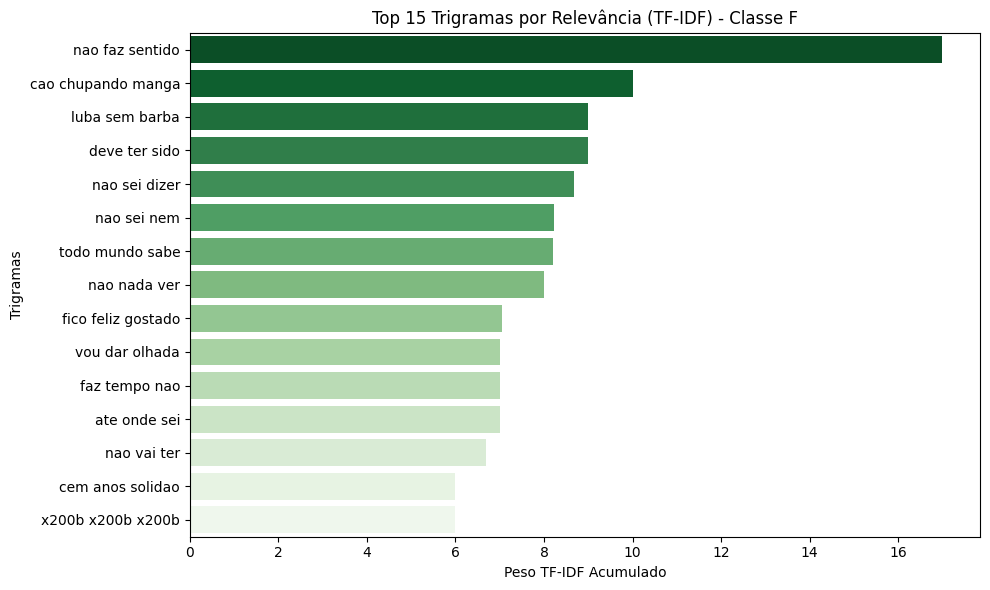

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analise_tfidf_trigramas(df):
    # ngram_range=(3, 3) para extrair blocos de 3 palavras
    tfidf = TfidfVectorizer(ngram_range=(3, 3), max_features=100)
    
    for classe, cor in [('T', 'Reds_r'), ('F', 'Greens_r')]:
        # Filtragem segura para evitar erros com strings vazias
        textos = df[df['label'] == classe]['texto_limpo'].copy()
        textos = textos.dropna().astype(str)
        textos = textos[textos.str.strip() != ""] 
        
        if len(textos) == 0:
            print(f"Sem dados suficientes para a classe {classe}")
            continue

        try:
            # Ajusta e transforma os textos da classe específica
            matriz_tfidf = tfidf.fit_transform(textos)
            
            # Extrai os pesos e os nomes dos trigramas
            pesos = matriz_tfidf.sum(axis=0).A1
            termos = tfidf.get_feature_names_out()
            
            # Monta o DataFrame para visualização
            df_tfidf = pd.DataFrame({'termo': termos, 'peso': pesos})
            df_tfidf = df_tfidf.sort_values(by='peso', ascending=False).head(15)
            
            # Geração do Gráfico
            plt.figure(figsize=(10, 6))
            sns.barplot(x='peso', y='termo', data=df_tfidf, hue='termo', palette=cor, legend=False)
            plt.title(f'Top 15 Trigramas por Relevância (TF-IDF) - Classe {classe}')
            plt.xlabel('Peso TF-IDF Acumulado')
            plt.ylabel('Trigramas')
            plt.tight_layout() # Garante que os textos longos não cortem na imagem
            plt.show()
            
        except ValueError:
            print(f"Não foi possível extrair trigramas para a classe {classe} (frases muito curtas).")

# ==========================================
# EXECUÇÃO 
# ==========================================
df_treino = pd.read_csv('dataset_treino_enriquecido.csv')
analise_tfidf_trigramas(df_treino)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Carregar as bases que separamos
df_treino = pd.read_csv('dataset_treino_enriquecido.csv')
df_teste = pd.read_csv('dataset_teste_puro.csv')

# Limpeza de segurança (remover nulos que podem quebrar o vetorizador)
df_treino = df_treino.dropna(subset=['texto_limpo', 'label'])
df_teste = df_teste.dropna(subset=['texto_limpo', 'label'])

# 2. Configurar o TF-IDF Global do Modelo
# Usamos ngram_range=(1, 2) para pegar palavras isoladas (unigramas) E pares (bigramas)
# max_features limita o tamanho do vocabulário para as palavras mais importantes, evitando que a RAM estoure
tfidf_modelo = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# 3. Vetorizar o Treino (FIT + TRANSFORM)
# O modelo LÊ o texto do treino, aprende o vocabulário e transforma em números
X_treino = tfidf_modelo.fit_transform(df_treino['texto_limpo'])
y_treino = df_treino['label']

# 4. Vetorizar o Teste (APENAS TRANSFORM)
# O modelo NÃO APRENDE palavras novas aqui. Ele apenas converte o teste 
# usando o vocabulário que já decorou no passo anterior.
X_teste = tfidf_modelo.transform(df_teste['texto_limpo'])
y_teste = df_teste['label']

print("Matrizes matemáticas prontas para o treinamento!")
print(f"Dimensões de X_treino: {X_treino.shape} (Mensagens, Vocabulário)")
print(f"Dimensões de X_teste:  {X_teste.shape} (Mensagens, Vocabulário)")

Matrizes matemáticas prontas para o treinamento!
Dimensões de X_treino: (15408, 5000) (Mensagens, Vocabulário)
Dimensões de X_teste:  (3849, 5000) (Mensagens, Vocabulário)


Treinando o modelo SVM... (Isso pode levar alguns segundos)
Treinamento concluído!

RELATÓRIO DE CLASSIFICAÇÃO (Classification Report)
              precision    recall  f1-score   support

           F       0.84      0.71      0.77      2963
           T       0.36      0.54      0.43       886

    accuracy                           0.67      3849
   macro avg       0.60      0.63      0.60      3849
weighted avg       0.73      0.67      0.69      3849



<Figure size 800x600 with 0 Axes>

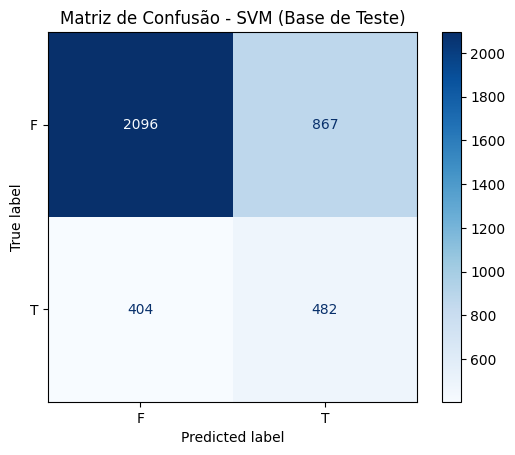

In [19]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar o Modelo SVM Linear
# random_state garante reprodutibilidade. class_weight='balanced' ajuda 
# caso a classe 'T' ainda seja menor que a 'F', dando mais peso aos erros nela.
svm_modelo = LinearSVC(random_state=42, class_weight='balanced')

print("Treinando o modelo SVM... (Isso pode levar alguns segundos)")

# 2. Treinamento (FIT) - A IA está aprendendo os padrões matemáticos
svm_modelo.fit(X_treino, y_treino)

print("Treinamento concluído!")

# 3. Previsão (PREDICT) - A IA agora tenta adivinhar a base de Teste (Mundo Real)
previsoes = svm_modelo.predict(X_teste)

# 4. Avaliação de Desempenho (Métricas para o seu TCC)
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO (Classification Report)")
print("="*50)
print(classification_report(y_teste, previsoes))

# 5. Gerar a Matriz de Confusão (Excelente gráfico para o artigo)
cm = confusion_matrix(y_teste, previsoes, labels=svm_modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_modelo.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - SVM (Base de Teste)')
plt.show()

Treinando o modelo SVM Otimizado...
Treinamento concluído!

RELATÓRIO DE CLASSIFICAÇÃO (SVM OTIMIZADO)
              precision    recall  f1-score   support

           F       0.85      0.73      0.79      2963
           T       0.39      0.56      0.46       886

    accuracy                           0.69      3849
   macro avg       0.62      0.65      0.62      3849
weighted avg       0.74      0.69      0.71      3849



<Figure size 800x600 with 0 Axes>

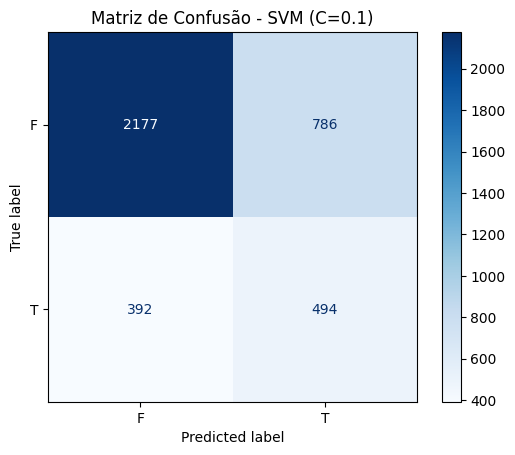

In [20]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar o Modelo SVM Linear OTIMIZADO
# Adicionamos C=0.1 para reduzir a paranoia (Falsos Positivos)
# max_iter=5000 garante que o modelo tenha tempo para achar a melhor fronteira matemática
svm_modelo = LinearSVC(C=0.1, max_iter=5000, random_state=42, class_weight='balanced')

print("Treinando o modelo SVM Otimizado...")

# 2. Treinamento
svm_modelo.fit(X_treino, y_treino)

print("Treinamento concluído!")

# 3. Previsão na base de Teste
previsoes = svm_modelo.predict(X_teste)

# 4. Avaliação de Desempenho
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO (SVM OTIMIZADO)")
print("="*50)
print(classification_report(y_teste, previsoes))

# 5. Matriz de Confusão
cm = confusion_matrix(y_teste, previsoes, labels=svm_modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_modelo.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - SVM (C=0.1)')
plt.show()

Treinando o modelo Naive Bayes...
Treinamento concluído!

RELATÓRIO DE CLASSIFICAÇÃO (NAIVE BAYES)
              precision    recall  f1-score   support

           F       0.83      0.88      0.85      2963
           T       0.50      0.40      0.44       886

    accuracy                           0.77      3849
   macro avg       0.66      0.64      0.65      3849
weighted avg       0.75      0.77      0.76      3849



<Figure size 800x600 with 0 Axes>

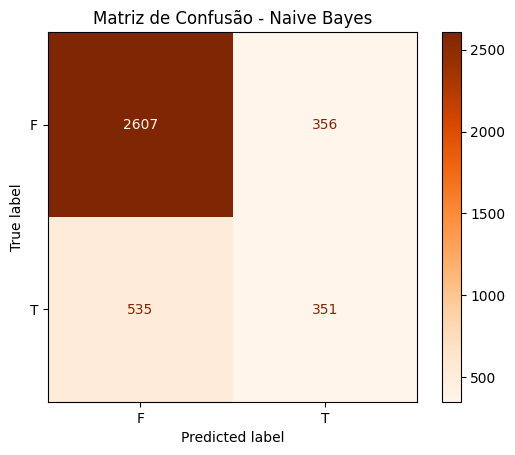

In [21]:
#Nayve

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar o Modelo Naive Bayes Multinomial
# O parâmetro alpha=1.0 aplica a "Suavização de Laplace"
# Isso impede que o modelo quebre (multiplique por zero) se o teste 
# tiver uma palavra inédita que passou pela vetorização.
nb_modelo = MultinomialNB(alpha=1.0)

print("Treinando o modelo Naive Bayes...")

# 2. Treinamento (FIT)
nb_modelo.fit(X_treino, y_treino)

print("Treinamento concluído!")

# 3. Previsão na base de Teste (Mundo Real)
previsoes_nb = nb_modelo.predict(X_teste)

# 4. Avaliação de Desempenho
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO (NAIVE BAYES)")
print("="*50)
print(classification_report(y_teste, previsoes_nb))

# 5. Matriz de Confusão para o Artigo
cm = confusion_matrix(y_teste, previsoes_nb, labels=nb_modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_modelo.classes_)

plt.figure(figsize=(8, 6))
# Usando a cor 'Oranges' para você ter gráficos de cores diferentes no artigo (SVM = Azul, NB = Laranja)
disp.plot(cmap='Oranges', values_format='d') 
plt.title('Matriz de Confusão - Naive Bayes')
plt.show()